In [2]:
import cv2 as cv
import mediapipe as mp
import csv
import os
import time

CSV_FILE = "focus_data.csv"
VIDEO_DIR = "recorded_videos"
RECORDING_DURATION = 20

if not os.path.exists(VIDEO_DIR):
    os.makedirs(VIDEO_DIR)
    
CLASSES = {
    ord('0') : "Focused",
    ord('1') : "Head Turned",
    ord('2') : "Looking Down",
    ord('3') : "Eyes Distracted",
    ord('4') : "Drowsy",
}

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(refine_landmarks= True)

cap = cv.VideoCapture(0)

recording = False
current_class_id = None
current_class_name = ""
video_writer = None
start_time = 0

if not os.path.exists(CSV_FILE):
    with open (CSV_FILE,'w',newline='') as f:
        writer = csv.writer(f)
        header = ['class_id'] + [f'{ax}{i}' for i in range(478) for ax in ['x','y','z']]
        writer.writerow(header)
        
print("Press keys 0-4 to start recording for each class. Press Enter to stop recording manually. Press 'q' to quit.")

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break
    
    frame = cv.flip(frame,1)
    h,w,_ = frame.shape
    display_frame = frame.copy()
    
    # Processign landmarks
    rgb_frame = cv.cvtColor(frame,cv.COLOR_BGR2RGB)
    results = face_mesh.process(rgb_frame)
    
    elapsed_time = 0
    if recording :

        elapsed_time = time.time() - start_time
        
        if elapsed_time >= RECORDING_DURATION:
            recording = False
            if video_writer:
                video_writer.release()
                video_writer = None
            print(f"AUTO-STOPPED: {current_class_name} session complete.")
        else:
            time_left = int(RECORDING_DURATION - elapsed_time)
            cv.circle(display_frame, (w - 30, 30), 15, (0, 0, 255), -1)
            cv.putText(display_frame,
                   f"REC: {current_class_name} | {time_left}s left",
                   (10, 70),
                   cv.FONT_HERSHEY_SIMPLEX,
                   0.8,
                   (0, 0, 255),
                   2)
            
            if results.multi_face_landmarks:
                video_writer.write(frame)
                
                for face_landmarks in results.multi_face_landmarks:
                    # class label
                    landmarks_row = [current_class_id]
                    for lm in face_landmarks.landmark:
                        landmarks_row.extend([lm.x,lm.y,lm.z])
                        
                    with open(CSV_FILE,mode='a',newline='') as f:
                        csv.writer(f).writerow(landmarks_row)
                        
                time_left = int(RECORDING_DURATION - elapsed_time)
                cv.circle(display_frame,(w - 30, 30), 15, (0, 0, 255), -1)
                cv.putText(display_frame,f"REC: {current_class_id}" ,(10,60),cv.FONT_HERSHEY_COMPLEX,1,(0,0,255),2)
        
    key = cv.waitKey(1) & 0xFF
    
    if key in CLASSES and not recording:
        recording = True
        current_class_id = int(chr(key))
        current_class_name = CLASSES[key]
        start_time = time.time()
        
        timestamp = int(time.time())
        vid_path = os.path.join(VIDEO_DIR,f"{current_class_name}_{timestamp}.avi")
        fourcc = cv.VideoWriter_fourcc(*'mp4v')
        video_writer = cv.VideoWriter(vid_path,fourcc,20,(w,h))
        print(f"STARTED Recording: {current_class_name}")
    elif key == 13 and recording:
        recording = False
        video_writer.release()
        video_writer = None
        print(f"STOPPED Recording: {current_class_name}")
        
    elif key == ord('q'):
        break
    
    cv.putText(display_frame, "0-4: START | ENTER: STOP | Q: QUIT", (10, 30), 
            cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    cv.imshow('Collector V2 (Dual-Stream)', display_frame)
cap.release()
if video_writer:
    video_writer.release()
cv.destroyAllWindows()

Press keys 0-4 to start recording for each class. Press Enter to stop recording manually. Press 'q' to quit.
STARTED Recording: Focused
AUTO-STOPPED: Focused session complete.
STARTED Recording: Head Turned
AUTO-STOPPED: Head Turned session complete.
STARTED Recording: Looking Down
AUTO-STOPPED: Looking Down session complete.
STARTED Recording: Eyes Distracted
STOPPED Recording: Eyes Distracted
STARTED Recording: Drowsy
STOPPED Recording: Drowsy


Loading data... please wait (it's a big file!)

--- DATA AUDIT ---
Class 0 (Focused): 1995 frames
Class 1 (Head Turned): 1768 frames
Class 2 (Looking Down): 1920 frames
Class 3 (Eyes Distracted): 1536 frames
Class 4 (Drowsy): 1937 frames

Generating 3D Head-Pose Map...


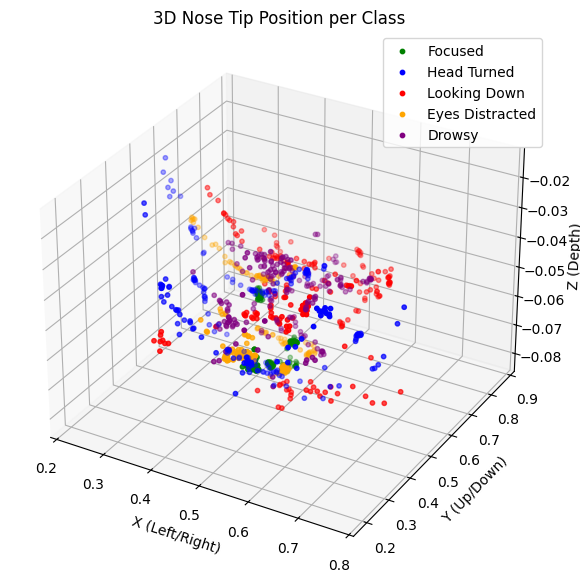

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Load the data
print("Loading data... please wait (it's a big file!)")
df = pd.read_csv("focus_data.csv")

# --- 📊 PART 1: THE AUDIT ---
print("\n--- DATA AUDIT ---")
class_counts = df['class_id'].value_counts().sort_index()
mapping = {0: "Focused", 1: "Head Turned", 2: "Looking Down", 3: "Eyes Distracted", 4: "Drowsy"}

for cid, count in class_counts.items():
    print(f"Class {cid} ({mapping[cid]}): {count} frames")

# --- 📈 PART 2: THE VISUALIZER ---
# Let's plot the Nose Tip (Landmark 4) to see the head movement
print("\nGenerating 3D Head-Pose Map...")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# We pick a few classes to compare: Focused (0), Turned (1), Down (2)
colors = {0: 'green', 1: 'blue', 2: 'red', 3: 'orange', 4: 'purple'}

# Plot a sample of 100 points from each class so the graph isn't too crowded
for cid in df['class_id'].unique():
    subset = df[df['class_id'] == cid].sample(n=min(200, len(df[df['class_id'] == cid])))
    
    # Landmark 4 is the tip of the nose
    ax.scatter(subset['x4'], subset['y4'], subset['z4'], 
               c=colors.get(cid, 'black'), label=mapping.get(cid, f"Class {cid}"), s=10)

ax.set_title("3D Nose Tip Position per Class")
ax.set_xlabel("X (Left/Right)")
ax.set_ylabel("Y (Up/Down)")
ax.set_zlabel("Z (Depth)")
ax.legend()
plt.show()